In [ ]:
# Copyright (c) 2025, Meredith Lochhead
# All rights reserved.
#
# This source code is licensed under the BSD 3-Clause License found in the
# LICENSE file in the root directory of this source tree.

In [3]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import folium 
import contextily as ctx
import os
import sys
from matplotlib.patches import Patch
from shapely.geometry import box
from matplotlib.ticker import ScalarFormatter, MaxNLocator
import seaborn as sns
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

# Import functions for inventory generation 
parent_dir = os.path.abspath(os.path.join(os.getcwd(), ".."))
fxn_dir = os.path.join(parent_dir, "inventory_generation_functions")
sys.path.append(fxn_dir)

import functions_general as fxns
import functions_preprocessing as pre 
import functions_point_to_ftpt as pt_ftpt 
import functions_disagreement_and_gaps as resolve

In [4]:
# Figure Directory 
fig_dir = './Figures/General/'
os.makedirs(fig_dir, exist_ok=True)

# Specify resolution of images 
dpi = 500

In [5]:
# Set plotting CRS values for data manipulation and plotting
crs_main = '26910' # Used for data manipulation and storage
crs_plot = '4269' # Used for plotting 

# HAYWARD BOUNDS
xbounds = [-122.15, -122.02]
ybounds = [37.60, 37.69]

# Define the color palette
stanford_palette = [
    "#034185", 
    "#a14059",  
    "#277b8eff",  
    "#ace1fbff",    
    "#a7a7d6ff"]

# Set the palette in seaborn
sns.set_palette(sns.color_palette(stanford_palette))
colors = stanford_palette

### EXAMPLES OF LACK OF 1:1 BETWEEN POINTS AND FOOTPRINTS

In [ ]:
# Load Raw NSI and footprints
rawnsi = fxns.json_to_gdf('./Input_Data/ProcessedData/National/Intermediate/Hayward_NSI.json', crs_main)
footprints = fxns.json_to_gdf('./Input_Data/ProcessedFootprints/Hayward_Footprints.json', crs_main)

rawnsi = rawnsi.to_crs(crs_plot)
footprints = footprints.to_crs(crs_plot)

In [ ]:
bb1 = box(-122.151868,37.619049,-122.10785,37.64101)
bb2 = box(-122.151868,37.621,-122.120847,37.636533)
bb3 = box(-122.14,37.621049,-122.120847,37.636533)
bb4 = box(-122.127446,37.630148,-122.1213,37.632527)


bb = bb3
bb_coords = list(bb.exterior.coords)
trim_raw = rawnsi[rawnsi.geometry.intersects(bb)]
trim_ftpt = footprints[footprints.geometry.intersects(bb)]
fig, ax = plt.subplots(1, 1, figsize=(8, 8), sharex = True, sharey=True, dpi = dpi)
trim_ftpt.plot(ax=ax,legend=True, color = 'tab:blue', alpha = 0.3)
trim_raw.plot(ax=ax, markersize=7, legend=True, color = 'k', alpha = 1)
ctx.add_basemap(ax, crs='EPSG:4326', source=ctx.providers.CartoDB.PositronNoLabels, zoom=16)

gdf_bb = gpd.GeoDataFrame({"geometry": [bb4]}, crs=crs_plot)
gdf_bb.boundary.plot(ax=ax, edgecolor="black", linewidth=2)
plt.xlim([bb_coords[2][0], bb_coords[0][0]])
plt.ylim([bb_coords[0][1], bb_coords[2][1]])
# ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
# ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
# ax.xaxis.set_major_locator(MaxNLocator(nbins=7))  # Adjust `nbins` as needed for fewer ticks

# Create legend manually with proxy artists
legend_patches = [
    mpatches.Patch(color='tab:blue', alpha = 0.3, label='Footprints'),
    mlines.Line2D([], [], marker='o', color='w', markerfacecolor='k', markersize=7, label='NSI Points')]
# legend = ax.legend(handles=legend_patches, loc='lower left', fontsize = 15, frameon=True, facecolor='white',edgecolor='white')

ax.set_xticks([])  # Remove x-axis ticks
ax.set_yticks([])  # Remove y-axis ticks
ax.set_xticklabels([])  # Remove x-axis labels
ax.set_yticklabels([])  # Remove y-axis labels
fig.savefig(fig_dir + "points_ftpts1.svg", format="svg",  bbox_inches='tight', pad_inches=0)
fig.savefig(fig_dir + "points_ftpts1.png",  bbox_inches='tight', pad_inches=0)
plt.close()



bb = bb4
bb_coords = list(bb.exterior.coords)
trim_raw = rawnsi[rawnsi.geometry.intersects(bb)]
trim_ftpt = footprints[footprints.geometry.intersects(bb)]
fig, ax = plt.subplots(1, 1, figsize=(8, 8), sharex = True, sharey=True, dpi = dpi)
trim_ftpt.plot(ax=ax,legend=True, color = 'tab:blue', alpha = 0.3)
trim_raw.plot(ax=ax, markersize=7, legend=True, color = 'k', alpha = 1)
ctx.add_basemap(ax, crs='EPSG:4326', source=ctx.providers.CartoDB.PositronNoLabels, zoom = 18)

gdf_bb = gpd.GeoDataFrame({"geometry": [bb4]}, crs=crs_plot)
gdf_bb.boundary.plot(ax=ax, edgecolor="red", linewidth=2, alpha = 0)

plt.xlim([bb_coords[2][0], bb_coords[0][0]])
plt.ylim([bb_coords[0][1], bb_coords[2][1]])
# ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
# ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
# ax.xaxis.set_major_locator(MaxNLocator(nbins=7))  # Adjust `nbins` as needed for fewer ticks

# legend = ax.legend(handles=legend_patches, loc='lower left', fontsize = 15, frameon=True, facecolor='white',edgecolor='white')

ax.set_xticks([])  # Remove x-axis ticks
ax.set_yticks([])  # Remove y-axis ticks
ax.set_xticklabels([])  # Remove x-axis labels
ax.set_yticklabels([])  # Remove y-axis labels
fig.savefig(fig_dir + "points_ftpts2.svg", format="svg",  bbox_inches='tight', pad_inches=0)
fig.savefig(fig_dir + "points_ftpts2.png",  bbox_inches='tight', pad_inches=0)
plt.close()

In [ ]:
bb1 = box(-122.0834461056,37.6402982151,-122.0812324188,37.6418967353)

bb = bb1
bb_coords = list(bb.exterior.coords)
trim_raw = rawnsi[rawnsi.geometry.intersects(bb)]
trim_ftpt = footprints[footprints.geometry.intersects(bb)]
fig, ax = plt.subplots(1, 1, figsize=(8, 8), sharex = True, sharey=True, dpi = dpi)
trim_ftpt.plot(ax=ax,legend=True, color = 'tab:blue', alpha = 0.3)
trim_raw.plot(ax=ax, markersize=7, legend=True, color = 'k', alpha = 1)
ctx.add_basemap(ax, crs='EPSG:4326', source=ctx.providers.CartoDB.PositronNoLabels, zoom=18)
plt.xlim([bb_coords[2][0], bb_coords[0][0]])
plt.ylim([bb_coords[0][1], bb_coords[2][1]])
ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.xaxis.set_major_locator(MaxNLocator(nbins=7))  # Adjust `nbins` as needed for fewer ticks

ax.set_xticks([])  # Remove x-axis ticks
ax.set_yticks([])  # Remove y-axis ticks
ax.set_xticklabels([])  # Remove x-axis labels
ax.set_yticklabels([])  # Remove y-axis labels

gdf_bb = gpd.GeoDataFrame({"geometry": [bb1]}, crs=crs_plot)
gdf_bb.boundary.plot(ax=ax, edgecolor="red", linewidth=2, alpha = 0)

# legend = ax.legend(handles=legend_patches, loc='lower left', fontsize = 15, frameon=True, facecolor='white',edgecolor='white')

fig.savefig(fig_dir + "points_ftpts3.svg", format="svg",  bbox_inches='tight', pad_inches=0)
fig.savefig(fig_dir + "points_ftpts3.png",  bbox_inches='tight', pad_inches=0)
plt.close()


### EXAMPLES OF LACK OF 1:1 BETWEEN PARCELS AND FOOTPRINTS

In [ ]:
# Load Raw NSI and footprints
parcels = gpd.read_file('./Input_Data/Local/Hayward_Parcels.geojson')
footprints = fxns.json_to_gdf('./Input_Data/ProcessedFootprints/Hayward_Footprints.json', crs_main)

parcels = parcels.to_crs(crs_plot)
footprints = footprints.to_crs(crs_plot)

In [ ]:
# Plot 

bb1 = box(-122.0950951185,37.6241732561,-122.0930672814,37.6251844667)
bb2 = box(-122.0940913751,37.6316193302,-122.090213717,37.6340895265)
bb3 = box(-122.0800665653,37.6372075647,-122.077035175,37.6394902356)
counter = 1

for bb in [bb1, bb2, bb3]:
    # Trim geometry based on bounding box to speed up plotting
    bb_coords = list(bb.exterior.coords)
    trim_parcel = parcels[parcels.geometry.intersects(bb)]
    trim_ftpt = footprints[footprints.geometry.intersects(bb)]

    # Create plot
    fig, ax = plt.subplots(1, 1, figsize=(8, 8), sharex = True, sharey=True, dpi = dpi)
    trim_ftpt.plot(ax=ax,legend=True, color = 'tab:blue', alpha = 0.4)
    trim_parcel.plot(ax=ax,legend=True, color = 'none', alpha = 1, edgecolor = 'black', linewidth = 2.5)
    ctx.add_basemap(ax, crs='EPSG:4326', source=ctx.providers.CartoDB.PositronNoLabels, zoom=19)

    # Add (transparent) box to reduce distortion
    gdf_bb = gpd.GeoDataFrame({"geometry": [bb]}, crs=crs_plot)
    gdf_bb.boundary.plot(ax=ax, edgecolor="black", linewidth=2, alpha = 0)

    # Specify plot bounds based on bounding box  
    plt.xlim([bb_coords[2][0], bb_coords[0][0]])
    plt.ylim([bb_coords[0][1], bb_coords[2][1]])

    # Axis formatting -- not used now, labels are removed 
    ax.set_xticks([])  # Remove x-axis ticks
    ax.set_yticks([])  # Remove y-axis ticks
    ax.set_xticklabels([])  # Remove x-axis labels
    ax.set_yticklabels([])  # Remove y-axis labels

   
    fig.savefig(fig_dir + f"parcels_ftpts{counter}.png", bbox_inches='tight', pad_inches=0)
    fig.savefig(fig_dir + f"parcels_ftpts{counter}.svg", format="svg",  bbox_inches='tight', pad_inches=0)
    counter += 1
    plt.close()

In [ ]:
## CREATE LEGEND FOR ABOVE PLOTS 

# Define your legend patches
legend_patches = [
    mpatches.Patch(color='tab:blue', alpha=0.3, label='Footprints'),
    mlines.Line2D([], [], marker='o', color='w', markerfacecolor='k', markersize=7, label='NSI Points'),
    mpatches.Patch(facecolor='none', edgecolor='black', linewidth=3, label='Parcels')

]

# Create a new figure just for the legend
fig, ax = plt.subplots(figsize=(3, 2))  # Adjust size as needed
ax.axis('off')  # Hide the axes

# Add legend to the figure
legend = fig.legend(
    handles=legend_patches,
    loc='center',
    fontsize=15,
    frameon=True,
    facecolor='white',
    edgecolor='white'
)
fig.savefig(fig_dir + f"parcel_pt_ftpt_leged.png", bbox_inches='tight', pad_inches=0)
fig.savefig(fig_dir + f"parcel_pt_ftpt_leged.svg", format="svg",  bbox_inches='tight', pad_inches=0)
plt.close()


### COMPARE FOOTPRINT INVENTORIES

In [ ]:
# BRAILS MS Footprint/NSI Inventory
ms = gpd.read_file('./Input_Data/National/BRAILS_nsi_ms.geojson')
ms.to_crs(crs_main, inplace=True)

# BRAILS OSM Footprint/NSI Inventory
osm = gpd.read_file('./Input_Data/National/BRAILS_nsi_osm.geojson')
osm.to_crs(crs_main, inplace=True)

# BRAILS USASTR Footprint/NSI Inventory
usastr = gpd.read_file('./Input_Data/National/BRAILS_nsi_usastr.geojson')
usastr.to_crs(crs_main, inplace=True)

# Raw Overture Footprints
overture_ftpt = gpd.read_file('./Input_Data/National/Hayward_overture_June25.geojson')
overture_ftpt.to_crs(crs_main, inplace=True)

# Trim Overture Footprints to Hayward Size using census blocks
hayward_blocks = gpd.read_file('./Input_Data/Census/Census2010/Hayward_blocks.geojson')
hayward_tracts = gpd.read_file('./Input_Data/Census/Census2010/Hayward_tracts.geojson')
overture = pre.assign_footprint_block_and_track(overture_ftpt, hayward_tracts, hayward_blocks, 'GEOID10')

# RESET ALL WITH GEOMETRY
ms = ms.to_crs(crs_plot)
osm = osm.to_crs(crs_plot)
usastr = usastr.to_crs(crs_plot)
overture = overture.to_crs(crs_plot)
footprints = footprints.to_crs(crs_plot)


In [ ]:
# Plot bounding boxes
bb1 = box(-122.0821497463,37.6496114624,-122.0724289052,37.6553254895)
bb2 = box(-122.091127,37.636333,-122.080399,37.643282)
bb3 = box(-122.0644504123,37.6159794031,-122.0555097041,37.6215243623)
bb3 = box(-122.025927,37.645858,-122.003508,37.65832)
bb3 = box(-122.061719,37.629212,-122.042524,37.641299)


# Plot
fig, ax = plt.subplots(figsize=(7, 7), dpi = dpi)
footprints.plot(ax=ax, markersize=0.05, legend=True, color = 'k')

# Add the OpenStreetMap basemap
ctx.add_basemap(ax, crs='EPSG:4326', source=ctx.providers.CartoDB.VoyagerNoLabels)

for bound in [bb1,bb2,bb3]:
    gdf_bb = gpd.GeoDataFrame({"geometry": [bound]}, crs=crs_plot)
    gdf_bb.boundary.plot(ax=ax, edgecolor='tab:red', linewidth=2)

ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.xaxis.set_major_locator(MaxNLocator(nbins=6))  # Adjust `nbins` as needed for fewer ticks

plt.xlim(xbounds)
plt.ylim(ybounds)
plt.show()
fig.savefig(fig_dir + "ftpt_compare_summary.svg", format="svg",  bbox_inches='tight', pad_inches=0)
fig.savefig(fig_dir + "ftpt_compare_summary.png", bbox_inches='tight', pad_inches=0)
plt.close()

In [ ]:
counter = 0 
for bb in [bb1, bb2, bb3]:

    bb_coords = list(bb.exterior.coords)

    trim_ms = ms[ms.geometry.intersects(bb)]
    trim_osm = osm[osm.geometry.intersects(bb)]
    trim_usastr = usastr[usastr.geometry.intersects(bb)]
    trim_overture = overture[overture.geometry.intersects(bb)]
    trim_hayward = footprints[footprints.geometry.intersects(bb)]


    # Reproject GeoDataFrame to match basemap CRS (EPSG:3857) and plot
    fig, ax = plt.subplots(1, 5, figsize=(13, 3), sharex = True, sharey=True, dpi = dpi)
    trim_ms.plot(ax=ax[0], markersize=0.05, legend=True, color = 'k')
    trim_osm.plot(ax=ax[1], markersize=0.05, legend=True, color = 'k')
    trim_usastr.plot(ax=ax[2], markersize=0.05, legend=True, color = 'k')
    trim_overture.plot(ax=ax[3], markersize=0.05, legend=True, color = 'k')
    trim_hayward.plot(ax=ax[4], markersize=0.05, legend=True, color = 'k')

    # if bb == bb1: 
    #     ax[0].set_title('Microsoft')
    #     ax[1].set_title('OpenStreetMaps')
    #     ax[2].set_title('USA Structures')
    #     ax[3].set_title('Overture')
    #     ax[4].set_title('Hayward Source')

    # Add the OpenStreetMap basemap
    ctx.add_basemap(ax[0], crs='EPSG:4326', source=ctx.providers.CartoDB.VoyagerNoLabels)
    ctx.add_basemap(ax[1], crs='EPSG:4326', source=ctx.providers.CartoDB.VoyagerNoLabels)
    ctx.add_basemap(ax[2], crs='EPSG:4326', source=ctx.providers.CartoDB.VoyagerNoLabels)
    ctx.add_basemap(ax[3], crs='EPSG:4326', source=ctx.providers.CartoDB.VoyagerNoLabels)
    ctx.add_basemap(ax[4], crs='EPSG:4326', source=ctx.providers.CartoDB.VoyagerNoLabels)

    for i in range(5):
        gdf_bb = gpd.GeoDataFrame({"geometry": [bb1]}, crs=crs_plot)
        gdf_bb.boundary.plot(ax=ax[i], edgecolor="black", linewidth=2, alpha = 0)

    ax[0].set_xticks([])  # Remove x-axis ticks
    ax[0].set_yticks([])  # Remove y-axis ticks
    ax[0].set_xticklabels([])  # Remove x-axis labels
    ax[0].set_yticklabels([])  # Remove y-axis labels

    plt.xlim([bb_coords[2][0], bb_coords[0][0]])
    plt.ylim([bb_coords[0][1], bb_coords[2][1]])

    plt.tight_layout()

    fig.savefig(fig_dir+f"ftpt_compare_{counter}.svg", format="svg",  bbox_inches='tight', pad_inches=0)
    fig.savefig(fig_dir+f"ftpt_compare_{counter}.png", bbox_inches='tight', pad_inches=0)
    counter += 1
    plt.close()

### POINT TO FOOTPRINT ATTRIBUTION PROCESS

In [ ]:
# Load in all intermediate data 
nsi_orig = fxns.json_to_gdf('./Input_Data/ProcessedData/National/NSI_for_Merge.json', crs_main)
footprints = fxns.json_to_gdf('./Input_Data/ProcessedFootprints/Hayward_Footprints.json', crs_main)

# Load in all intermediate files
mf1 = fxns.json_to_gdf('./Inventory_Outputs/Synthesized_National/FootprintAttribution/Intermediate/MergeFlag1.json', crs_main)
mf2 = fxns.json_to_gdf('./Inventory_Outputs/Synthesized_National/FootprintAttribution/Intermediate/MergeFlag2.json', crs_main)
mf310 = fxns.json_to_gdf('./Inventory_Outputs/Synthesized_National/FootprintAttribution/Intermediate/MergeFlag310.json', crs_main)
mf3100 = fxns.json_to_gdf('./Inventory_Outputs/Synthesized_National/FootprintAttribution/Intermediate/MergeFlag3100.json', crs_main)

# Load Census blocks and tracts 
hayward_blocks = gpd.read_file('./Input_Data/Census/Census2010/Hayward_blocks.geojson')
hayward_tracts = gpd.read_file('./Input_Data/Census/Census2010/Hayward_tracts.geojson')


##### SPLIT DATA BASED ON DROP_FLAG AND FIND REMAINING POINTS #####
nsi = mf2.copy()
nsi0 = nsi[nsi['POINT_DropFlag']!=1] # Not dropped - these should be used in merge
nsi1 = nsi[nsi['POINT_DropFlag']==1] # Dropped - these should not be used in merge 
remaining_points, remaining_ftpt = pt_ftpt.find_remaining(nsi0, footprints, 'POINT_FootprintID','POINT_MergeFlag')

In [ ]:
# Specify blocks 
CB_ID1 = '060014363004014' 
CB_ID2 = '060014378001031'  

counter = 0 
for CB_ID in [CB_ID1, CB_ID2]:

    # Set title
    if CB_ID == CB_ID1: 
        title = True
    else:
        title = False
        
    fig, ax = plt.subplots(1,4, figsize = (15,5), sharex = True, sharey = True, dpi = dpi)

    msize = 5
    legend_loc = 'upper right'
    leg_font = 8
    title_font = 10
    cb_alpha = 0.25

    # Compute remaining data for each case
    nsi = mf2.copy()
    nsi0 = nsi[nsi['POINT_DropFlag']!=1] # Not dropped - these should be used in merge
    nsi1 = nsi[nsi['POINT_DropFlag']==1] # Dropped - these should not be used in merge 
    rp2, rf2 = pt_ftpt.find_remaining(nsi0, footprints, 'POINT_FootprintID','POINT_MergeFlag')


    # Separate out data for census block
    block = hayward_blocks[hayward_blocks['GEOID10']==CB_ID].copy()
    ftpt_cb = footprints[footprints['CensusBlock']==CB_ID].copy()
    nsi_orig_cb = nsi_orig[nsi_orig['CensusBlock']==CB_ID].copy()
    mf2_cb = mf2[mf2['CensusBlock']==CB_ID].copy()
    rp2_cb = rp2[rp2['CensusBlock']==CB_ID].copy()
    rf2_cb = rf2[rf2['CensusBlock']==CB_ID].copy()

    # Get data that is and is not dropped after intersection cases taken care of 
    rp2_drop = rp2_cb[rp2_cb['NSI_OccupancyClass'].isin(['GOV1', 'IND4','IND5'])].copy()
    rp2_nodrop = rp2_cb[~rp2_cb['NSI_OccupancyClass'].isin(['GOV1', 'IND4','IND5'])].copy()

    # Get data that has been merged 
    merged_intersected = mf2_cb[mf2_cb['POINT_MergeFlag'].isin([1.0,2.0,99])].copy()
    merged_nsi_ids = [item for sublist in merged_intersected['POINT_ID_List'] for item in (sublist if isinstance(sublist, list) else [sublist])]
    merged_nsi_points = nsi_orig_cb[nsi_orig_cb['POINT_ID'].isin(merged_nsi_ids)].copy()
    merged_ftpts = ftpt_cb[ftpt_cb['FootprintID'].isin(merged_intersected['POINT_FootprintID'].unique())].copy()

    # Get not full footprints 
    merged_99 = mf2_cb[mf2_cb['POINT_MergeFlag'].isin([99])].copy()
    ftpts_99 = ftpt_cb[ftpt_cb['FootprintID'].isin(merged_99['POINT_FootprintID'].unique())].copy()

    # Convert all data to plotting crs
    block.to_crs(crs_plot, inplace = True)
    ftpt_cb.to_crs(crs_plot, inplace = True)
    nsi_orig_cb.to_crs(crs_plot, inplace = True)
    rp2_drop.to_crs(crs_plot, inplace = True)
    rp2_nodrop.to_crs(crs_plot, inplace = True)
    rf2_cb.to_crs(crs_plot, inplace = True)
    merged_ftpts.to_crs(crs_plot, inplace = True)
    merged_nsi_points.to_crs(crs_plot, inplace = True)
    ftpts_99.to_crs(crs_plot, inplace = True)


    # Plot census block for all 
    for i in range(4):
        block.plot(ax=ax[i], alpha = cb_alpha, color = 'gray')

    # PLOT ALL POINTS AND FOOTPRINTS 
    ftpt_cb.plot(ax=ax[0], alpha = 0.6, color = 'gray')
    nsi_orig_cb.plot(ax=ax[0], color = 'black', markersize = msize)
    # Create legend 
    legend_patches = [
        mpatches.Patch(color='tab:gray', alpha = cb_alpha, label='Census Block'),
        mpatches.Patch(color='gray', alpha = 0.6, label='Footprints'),
        mlines.Line2D([],[], marker='o', color='w', markerfacecolor='k', markersize=msize, label='NSI Points')]
    legend = ax[0].legend(handles=legend_patches, loc=legend_loc, fontsize = leg_font, frameon=True, facecolor='white',edgecolor='gray')

    # PLOT POINTS AND FOOTPRINTS MERGED DURING INTERSECTION 
    merged_ftpts.plot(ax=ax[1], alpha = 0.6, color = 'tab:green')
    merged_nsi_points.plot(ax=ax[1], color = 'black', markersize = msize)
    # Create legend 
    legend_patches = [
        mpatches.Patch(color='tab:gray', alpha = cb_alpha, label='Census Block'),
        mpatches.Patch(color='tab:green', alpha = 0.6, label='Attributed Footprints'),
        mlines.Line2D([],[], marker='o', color='w', markerfacecolor='k', markersize=msize, label='Attributed Points')]
    legend = ax[1].legend(handles=legend_patches, loc=legend_loc, fontsize = leg_font, frameon=True, facecolor='white',edgecolor='gray')

    # PLOT REMAINING FOOTPRINTS, REMAINING POINTS, AND POINTS THAT GET DROPPED AFTER INTERSECTION. 
    # MARK WHICH FOOTPRINTS ARE EMPTY AND WHICH POINTS ARE ATTRIBUTED THERE 
    rf2_cb.plot(ax=ax[2], alpha = 0.6, color = 'tab:blue')
    if len(rp2_drop) > 0:
        rp2_drop.plot(ax = ax[2], color = 'tab:red', markersize = 20, marker = 'x')
    rp2_nodrop.plot(ax=ax[2], markersize = msize, color = 'tab:red')
    # Create legend 
    if len(rp2_drop) > 0:
        legend_patches = [
            mpatches.Patch(color='tab:gray', alpha = cb_alpha, label='Census Block'),
            mpatches.Patch(color='tab:blue', alpha = 0.6, label='Remaining Footprints'),
            mlines.Line2D([],[], marker='o', color='w', markerfacecolor='tab:red', markersize=msize, label='Remaining Points'),
            mlines.Line2D([], [], marker='x', color='tab:red', linestyle='None', markersize=msize, label='Points Dropped due to Occupancy Class')]
        legend = ax[2].legend(handles=legend_patches, loc=legend_loc, fontsize = leg_font, frameon=True, facecolor='white',edgecolor='gray')
    else:
        legend_patches = [
            mpatches.Patch(color='tab:gray', alpha = cb_alpha, label='Census Block'),
            mpatches.Patch(color='tab:blue', alpha = 0.6, label='Remaining Footprints'),
            mlines.Line2D([],[], marker='o', color='w', markerfacecolor='tab:red', markersize=msize, label='Remaining Points')]
        legend = ax[2].legend(handles=legend_patches, loc=legend_loc, fontsize = leg_font, frameon=True, facecolor='white',edgecolor='gray')

    # PLOT REMAINING FOOTPRINTS AND NOT FULL FOOTPRINTS 
    ftpts_99.plot(ax=ax[3], alpha = 0.6, color = colors[4])
    rf2_cb.plot(ax=ax[3], alpha = 0.6, color = 'tab:blue')
    rp2_nodrop.plot(ax=ax[3], markersize = msize, color = 'black')

    # Create legend 
    legend_patches = [
        mpatches.Patch(color='tab:gray', alpha = cb_alpha, label='Census Block'),
        mpatches.Patch(color='tab:blue', alpha = 0.6, label='Remaining Footprints'),
        mpatches.Patch(color=colors[4], alpha = 0.6, label='Not Full Footprints'),
        mlines.Line2D([],[], marker='o', color='w', markerfacecolor='k', markersize=msize, label='Attributed Points')]
    legend = ax[3].legend(handles=legend_patches, loc=legend_loc, fontsize = leg_font, frameon=True, facecolor='white',edgecolor='gray')

    # Remove all axes
    ax[0].set_xticks([])  # Remove x-axis ticks∂
    ax[0].set_yticks([])  # Remove y-axis ticks
    ax[0].set_xticklabels([])  # Remove x-axis labels
    ax[0].set_yticklabels([])  # Remove y-axis labels

    # Add title
    if title:
        ax[0].set_title('All Points and Footprints', fontsize = title_font)
        ax[1].set_title('Points Attributed to Footprints\nBased on Intersection', fontsize = title_font)
        ax[2].set_title('Remaining Points and Footprints', fontsize = title_font)
        ax[3].set_title('Points Attributed to Footprints,\nRemaining and "Not Full" Footprints', fontsize = title_font)


    # Add basemap 
    for i in range(4):
        ctx.add_basemap(ax[i], crs='EPSG:4326', source=ctx.providers.CartoDB.PositronNoLabels)
        block.plot(ax=ax[i], alpha = 0, color = 'gray')

    # Formatting
    plt.tight_layout()
    fig.savefig(fig_dir + f"point_attribution{counter}.svg", format="svg",  bbox_inches='tight', pad_inches=0)
    fig.savefig(fig_dir + f"point_attribution{counter}.png", bbox_inches='tight', pad_inches=0)
    counter += 1
    plt.close()

### EXAMPLES OF NSI RESIDENTIAL DATA WITHOUT TAX DATA

In [8]:
# Load Data
nsi = fxns.json_to_gdf('./Inventory_Outputs/Synthesized_National/FootprintAttribution/National_Inventory_Point.json', crs_main)
tax = fxns.json_to_gdf('./Inventory_Outputs/Synthesized_Local/FootprintAttribution/All_Local_Data_Attributed.json', crs_main)
footprints = fxns.json_to_gdf('./Input_Data/ProcessedFootprints/Hayward_Footprints.json', crs_main)


### FIND FOOTPRINTS THAT HAVE RESIDENTIAL NSI DATA, BUT NO CORRESPONDING TAX DATA ### 

# Drop columns that are shared between rows 
tax = tax.drop(columns = ['geometry', 'ftpt_geometry', 'FootprintArea', 'FootprintHeight', 'CensusBlock', 'CensusTract', 'Footprint_Flag'])

# Merge Data based on FootprintID and check no data is lost
alldata = gpd.GeoDataFrame(nsi.merge(tax, on='FootprintID', how='left'))
alldata['Local_Flag'] = alldata['Local_Flag'].fillna(0)
if (len(nsi) != len(alldata)):
    raise ValueError('Footprint data lost in merge')

# Find footprints that has residential NSI data, but no corresponding tax data 
nsi_only = alldata[(alldata['National_Flag']==1) & (alldata['Local_Flag']==0)]
res_types = ['RES1-1SNB', 'RES1-1SWB', 'RES1-2SNB', 'RES1-2SWB', 'RES1-3SNB', 'RES1-3SWB', 'RES1-SLNB', 'RES1-SLWB', 'RES1', 'RES2','RES3A', 'RES3B', 'RES3C', 'RES3D','RES3E', 'RES3F']
res_nsi_only = nsi_only[nsi_only['NSI_OccupancyClass'].apply(resolve.check_occupancy_class, args=(res_types,))]
res_nsi_only_ftpts = res_nsi_only['FootprintID'].tolist()

## GET FOOTPRINTS FOR PLOTTING 
ftpt_nsionly = footprints.loc[footprints['FootprintID'].isin(res_nsi_only_ftpts)]


## GET FOOTPRINTS THAT HAVE SOME DATA
only_ftpt = alldata[(alldata['Footprint_Flag']==1) & (alldata['National_Flag']==0) & (alldata['Local_Flag']==0)]
only_ftpt_ids = only_ftpt['FootprintID'].tolist()
ftpt_not_none = footprints.loc[~footprints['FootprintID'].isin(only_ftpt_ids)]


print(len(res_nsi_only), 'res footprints with nsi and no tax')
print(round(sum(res_nsi_only['NSI_ReplacementCost'])/10**6), ' million dollar total')
print((res_nsi_only['NSI_Population_Night'].sum()), 'nightime population')

1138 res footprints with nsi and no tax
1304  million dollar total
7541.0 nightime population


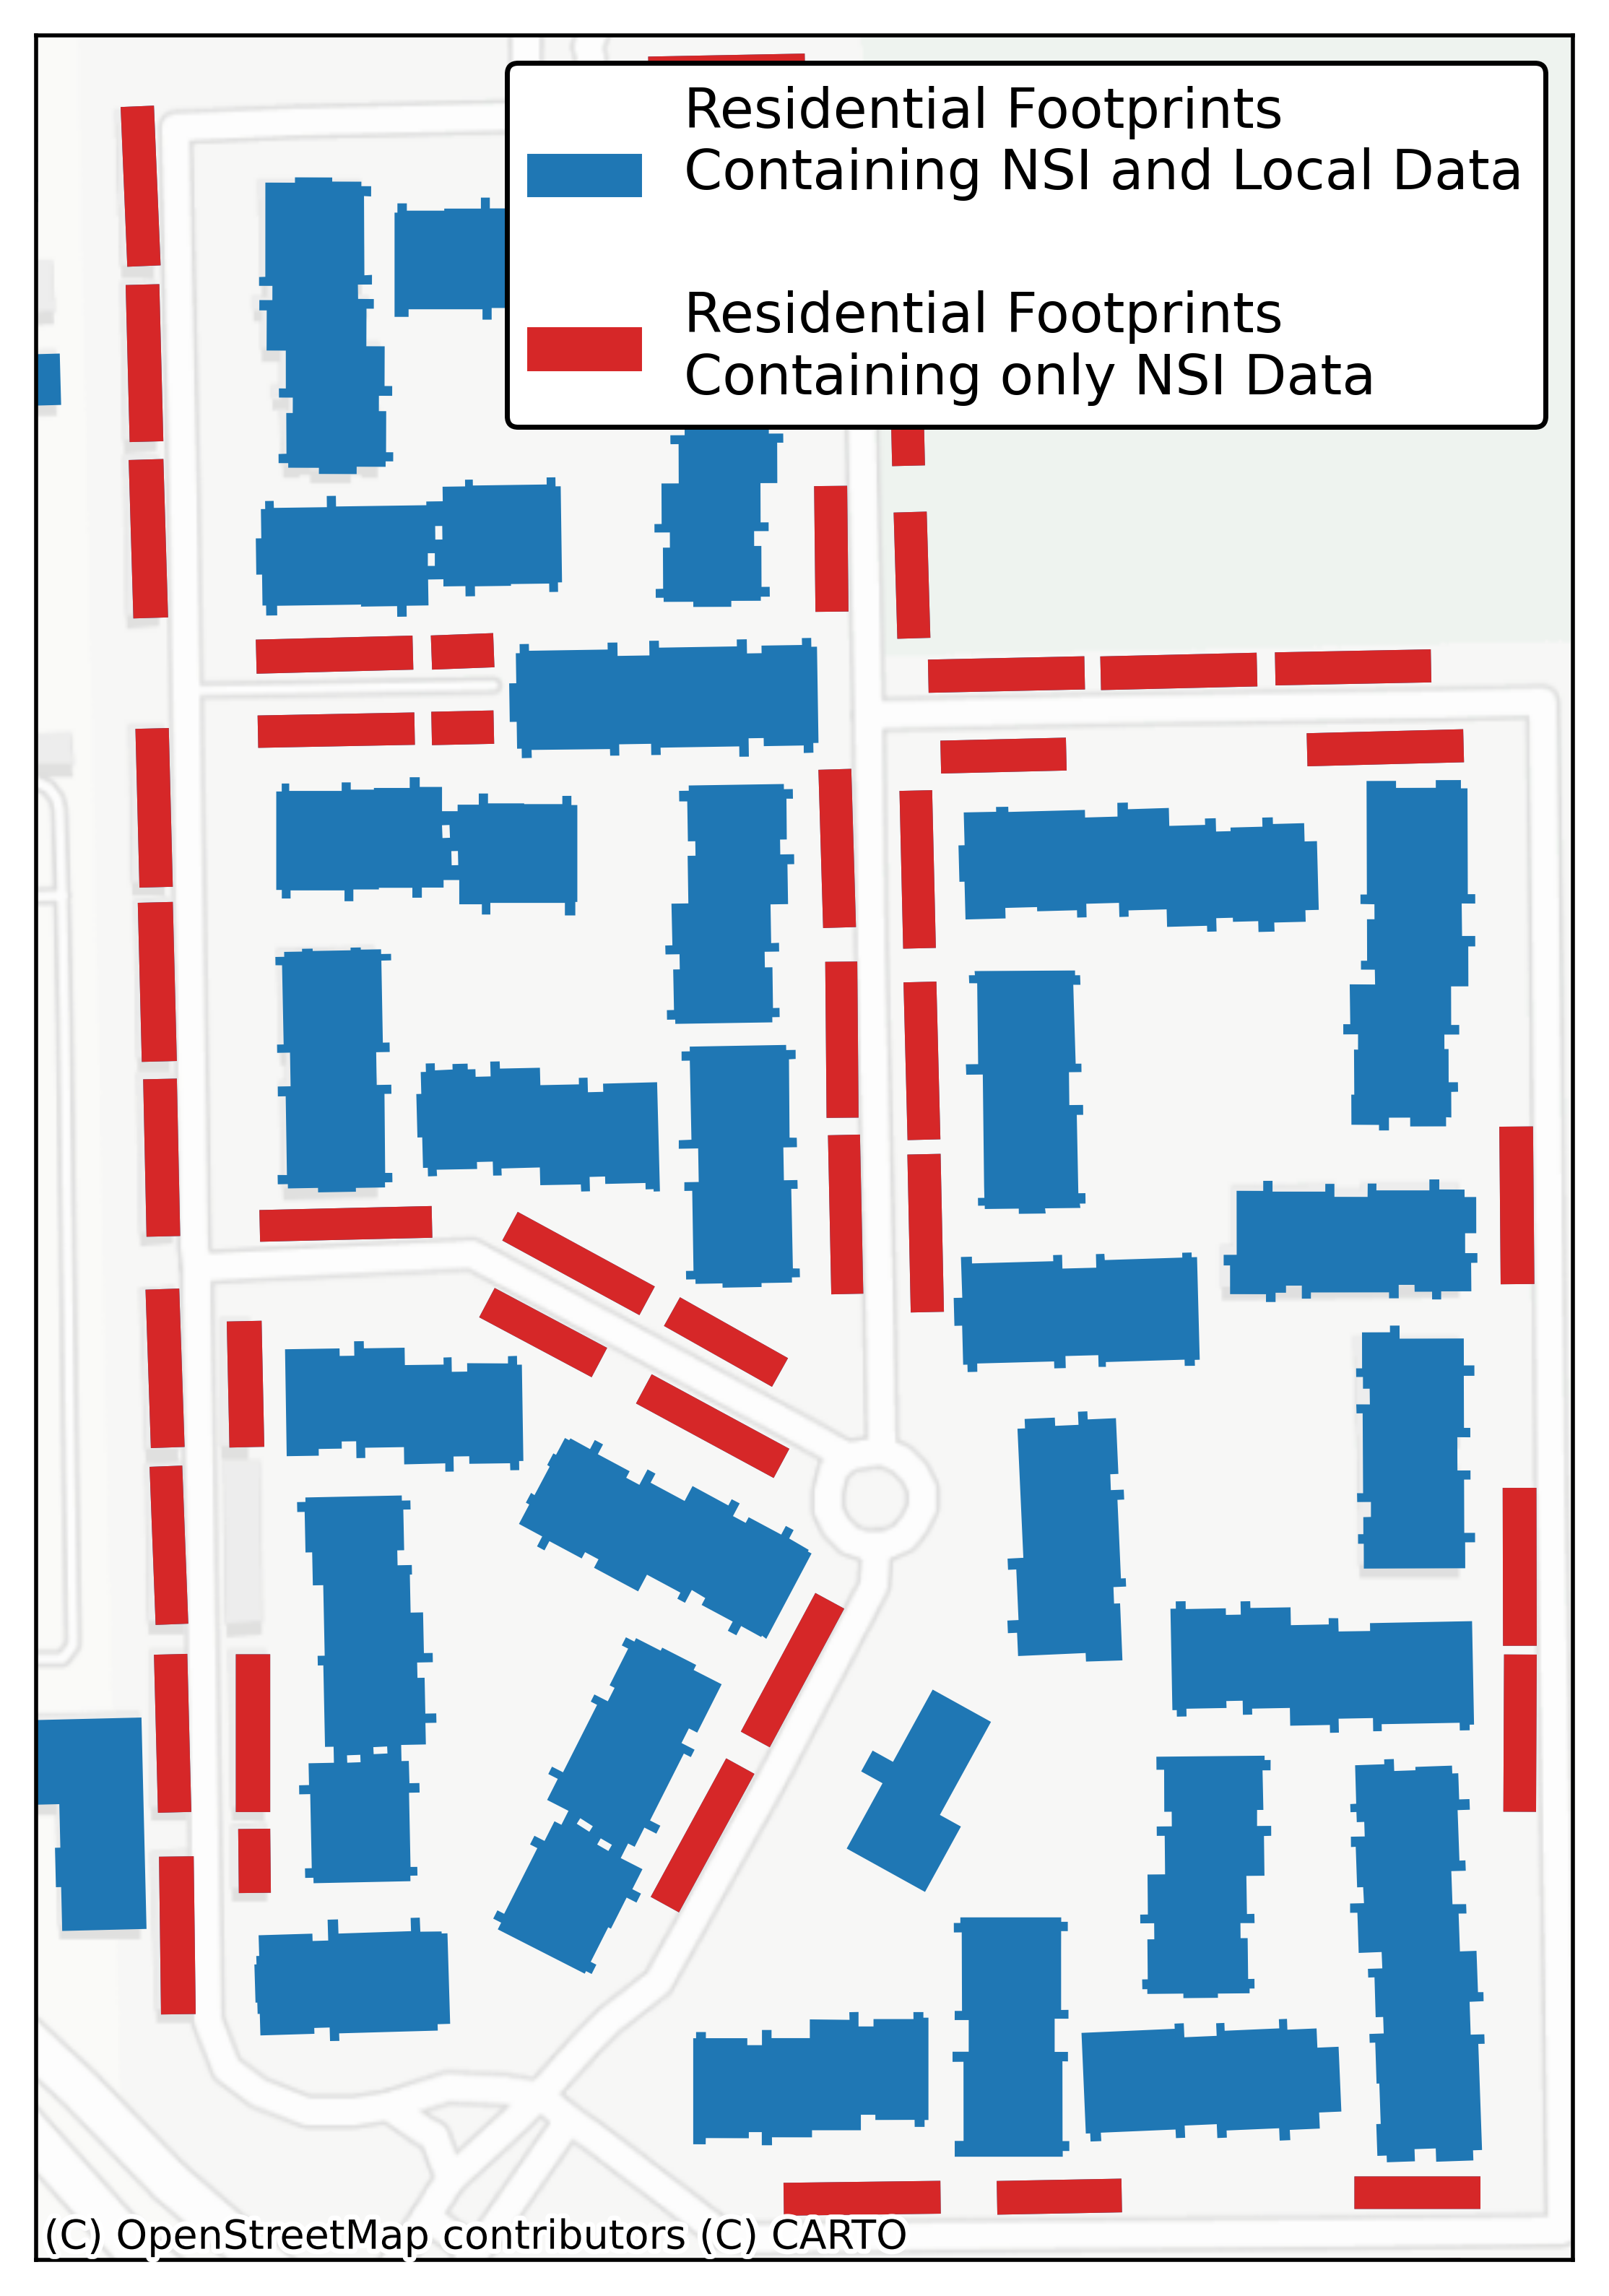

In [9]:
# Specify bounding box
bb = box(-122.1137406177,37.6351249652,-122.1106826581,37.638629769)

# Convert
ftpt_nsionly = ftpt_nsionly.to_crs(crs_plot)
ftpt_not_none = ftpt_not_none.to_crs(crs_plot)

# Create plot 
fig, ax = plt.subplots(1, 1, figsize=(8,8), dpi = dpi)

# Trim data for faster plotting
bb_coords = list(bb.exterior.coords)
trim_ftpt_nsionly = ftpt_nsionly[ftpt_nsionly.geometry.intersects(bb)]
trim_ftpt_not_none = ftpt_not_none[ftpt_not_none.geometry.intersects(bb)]

# Plot data
trim_ftpt_not_none.plot(ax=ax,color='tab:blue', markersize = 10, label = 'Footprints Containing NSI and Local Data')
trim_ftpt_nsionly.plot(ax=ax,color='tab:red', markersize = 10, label = 'Footprints Containing only NSI Data')
ctx.add_basemap(ax, crs='EPSG:4326', source=ctx.providers.CartoDB.PositronNoLabels, zoom=18)

# Add (transparent) box to reduce distortion
gdf_bb = gpd.GeoDataFrame({"geometry": [bb]}, crs=crs_plot)
gdf_bb.boundary.plot(ax=ax, edgecolor="red", linewidth=2, alpha = 0)

# Set axes
plt.xlim([bb_coords[2][0], bb_coords[0][0]])
plt.ylim([bb_coords[0][1], bb_coords[2][1]])
ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
ax.xaxis.set_major_locator(MaxNLocator(nbins=7))  # Adjust `nbins` as needed for fewer ticks
ax.set_xticks([])  # Remove x-axis ticks
ax.set_yticks([])  # Remove y-axis ticks
ax.set_xticklabels([])  # Remove x-axis labels
ax.set_yticklabels([])  # Remove y-axis labels

# Legend
legend_patches = [
    mpatches.Patch(color='tab:blue', label='Residential Footprints \nContaining NSI and Local Data\n'),
    mpatches.Patch(color='tab:red', label='Residential Footprints \nContaining only NSI Data')]
legend = ax.legend(handles=legend_patches, loc='upper right', fontsize = 11) #, frameon=True, facecolor='white',edgecolor='black')

# Ensure the legend background is fully opaque
legend.get_frame().set_facecolor('white')  # Set solid white background
legend.get_frame().set_edgecolor('black')  # Black border for clarity
legend.get_frame().set_alpha(1) 

fig.savefig(fig_dir + "reattribution.svg", format="svg",  bbox_inches='tight', pad_inches=0)
fig.savefig(fig_dir + "reattribution.png",  bbox_inches='tight', pad_inches=0)
# plt.close()